In [4]:
import pandas as pd
df = pd.read_csv('TSLA.csv')
print(df.head())

         Date   Open   High    Low  Close  Adj Close    Volume
0  2010-06-29  3.800  5.000  3.508  4.778      4.778  93831500
1  2010-06-30  5.158  6.084  4.660  4.766      4.766  85935500
2  2010-07-01  5.000  5.184  4.054  4.392      4.392  41094000
3  2010-07-02  4.600  4.620  3.742  3.840      3.840  25699000
4  2010-07-06  4.000  4.000  3.166  3.222      3.222  34334500


In [26]:
df.shape

(2956, 8)

This indicates that the dataset contains 2956 rows (observations) and 8 columns (features/variables).

In [5]:
#to check the values between close and adj close, if they match drop the duplicate column adj close
if 'Adj Close' in df.columns:
    if all(df['Close'] == df['Adj Close']):
        df.drop('Adj Close', axis=1, inplace=True)
print(df.head())

         Date   Open   High    Low  Close    Volume
0  2010-06-29  3.800  5.000  3.508  4.778  93831500
1  2010-06-30  5.158  6.084  4.660  4.766  85935500
2  2010-07-01  5.000  5.184  4.054  4.392  41094000
3  2010-07-02  4.600  4.620  3.742  3.840  25699000
4  2010-07-06  4.000  4.000  3.166  3.222  34334500


In [6]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2956 entries, 0 to 2955
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    2956 non-null   object 
 1   Open    2956 non-null   float64
 2   High    2956 non-null   float64
 3   Low     2956 non-null   float64
 4   Close   2956 non-null   float64
 5   Volume  2956 non-null   int64  
dtypes: float64(4), int64(1), object(1)
memory usage: 138.7+ KB
None


From the df.info() output, a key observation is that the 'Date' column is currently an object type, which should ideally be converted to a datetime format for proper time-series analysis. It also shows there are no null values in the dataset, as indicated by the non-null and count info.

In [7]:
print(df.describe())

              Open         High          Low        Close        Volume
count  2956.000000  2956.000000  2956.000000  2956.000000  2.956000e+03
mean    138.691296   141.771603   135.425953   138.762183  3.131449e+07
std     250.044839   255.863239   243.774157   250.123115  2.798383e+07
min       3.228000     3.326000     2.996000     3.160000  5.925000e+05
25%      19.627000    20.402000    19.127500    19.615000  1.310288e+07
50%      46.656999    47.487001    45.820002    46.545000  2.488680e+07
75%      68.057001    69.357500    66.911501    68.103998  3.973875e+07
max    1234.410034  1243.489990  1217.000000  1229.910034  3.046940e+08


A key observation from the df.describe() output for the Tesla dataset is the vast range in 'Close' prices, from a minimum of 3.16 to a maximum of 1229.91, highlighting significant price volatility over the observed period. The describe() function in pandas is a very useful method that generates descriptive statistics of a DataFrame's numerical columns. It provides a quick overview of the central tendency, dispersion, and shape of the distribution of a dataset.

In [8]:
print(df.isnull().sum())

Date      0
Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64


From the output, a key observation is that there are no missing values in any of the columns of the 'TSLA' dataset.

In [9]:
#to convert 'date' object to 'datetime' datatype
df['Date'] = pd.to_datetime(df['Date'])
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2956 entries, 0 to 2955
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    2956 non-null   datetime64[ns]
 1   Open    2956 non-null   float64       
 2   High    2956 non-null   float64       
 3   Low     2956 non-null   float64       
 4   Close   2956 non-null   float64       
 5   Volume  2956 non-null   int64         
dtypes: datetime64[ns](1), float64(4), int64(1)
memory usage: 138.7 KB
None


'Date' column has been successfully converted to 'datetime64[ns]' data type.

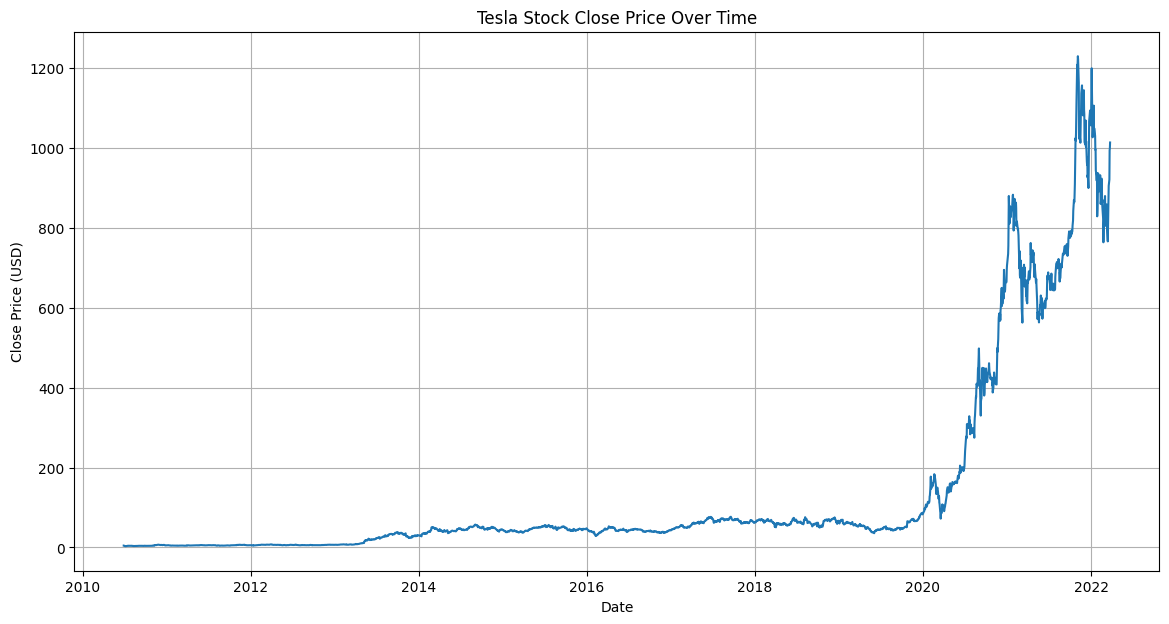

In [10]:
#Visualize the closing price of Tesla stock over time to identify trends.
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 7))
sns.lineplot(x='Date', y='Close', data=df)
plt.title('Tesla Stock Close Price Over Time')
plt.xlabel('Date')
plt.ylabel('Close Price (USD)')
plt.grid(True)
plt.show()

The plot reveals a general upward trend in Tesla's closing stock price, accompanied by significant volatility over the observed period.

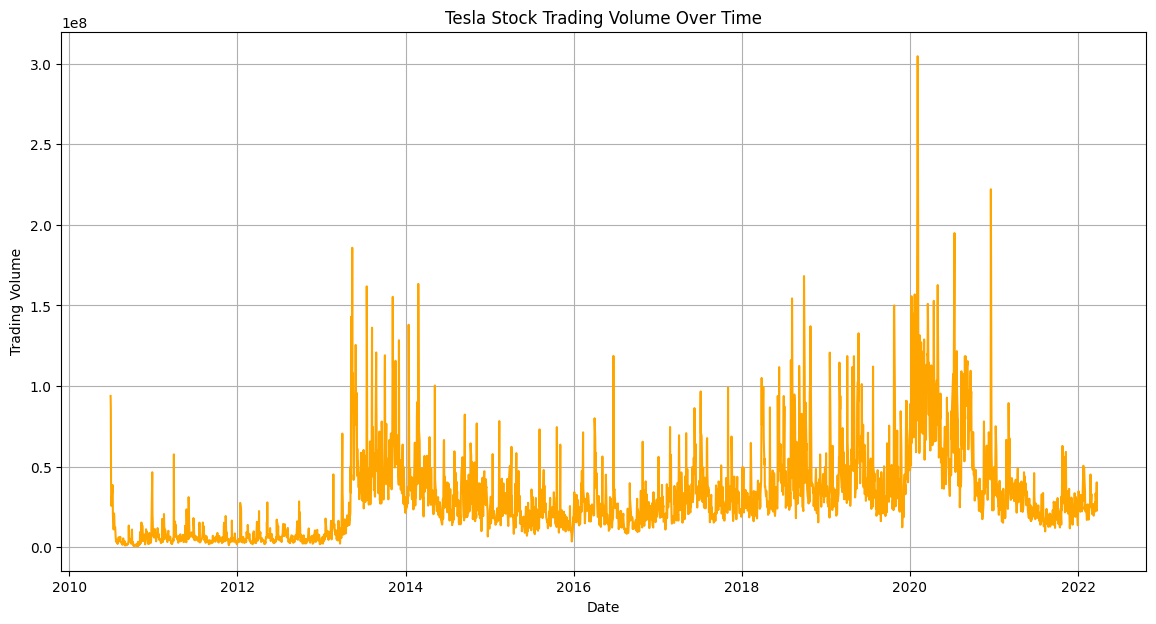

In [11]:
#Visualize the trading volume of Tesla stock over time to understand market activity.
plt.figure(figsize=(14, 7))
sns.lineplot(x='Date', y='Volume', data=df, color='orange')
plt.title('Tesla Stock Trading Volume Over Time')
plt.xlabel('Date')
plt.ylabel('Trading Volume')
plt.grid(True)
plt.show()

The plot illustrates significant fluctuations in Tesla's trading volume, suggesting periods of heightened investor interest and market activity.

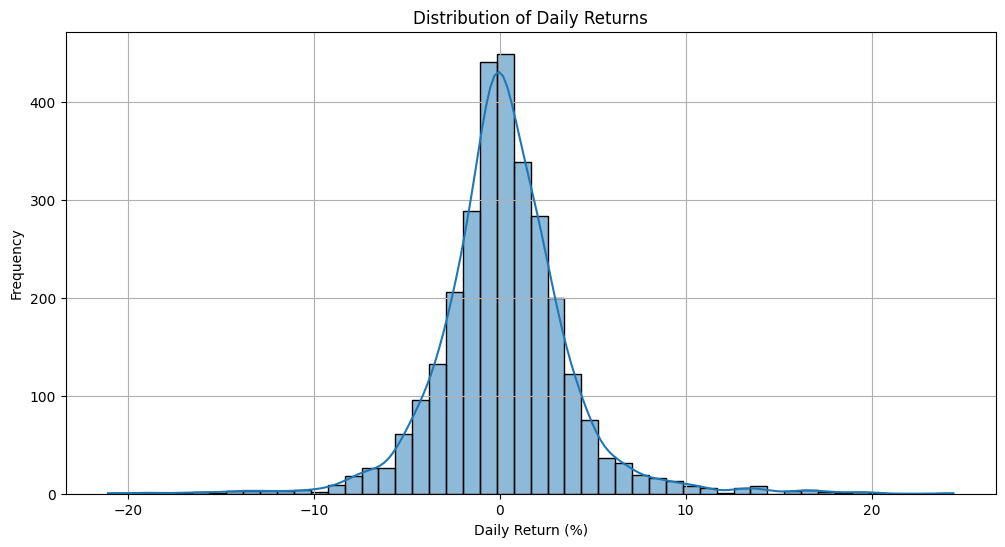

In [12]:
#daily returns distribution - daily percentage change in the 'Close' price and visualize its distribution using a histogram
#histograms cannot handle NaN values
df['Daily_Return'] = df['Close'].pct_change() * 100
plt.figure(figsize=(12, 6))
sns.histplot(df['Daily_Return'].dropna(), bins=50, kde=True) #dropna() because the first daily return value will be NaN
plt.title('Distribution of Daily Returns')
plt.xlabel('Daily Return (%)')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

The distribution of daily returns appears to be centered around zero, indicating that positive and negative returns are common, with a slightly higher frequency for returns closer to zero.

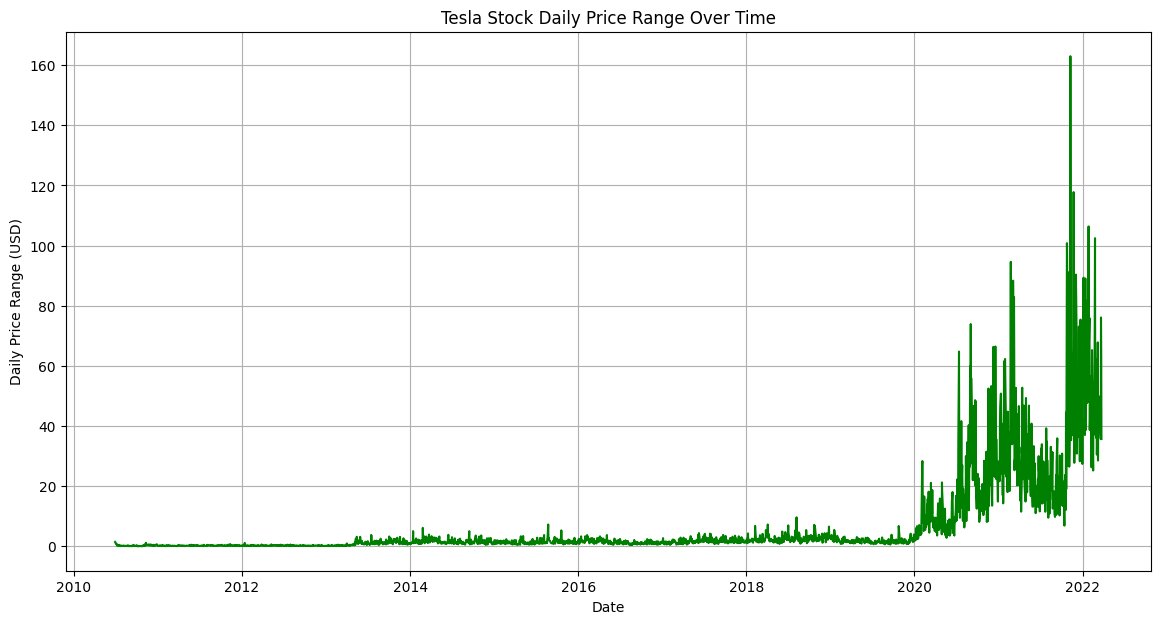

In [13]:
#daily price range (volatility) - difference between the 'high' and 'low' prices
df['Daily_Range'] = df['High'] - df['Low']
plt.figure(figsize=(14, 7))
sns.lineplot(x='Date', y='Daily_Range', data=df, color='green')
plt.title('Tesla Stock Daily Price Range Over Time')
plt.xlabel('Date')
plt.ylabel('Daily Price Range (USD)')
plt.grid(True)
plt.show()

The daily price range plot shows periods of increased volatility, especially during significant market events or growth phases for Tesla, as indicated by wider gaps between high and low prices.

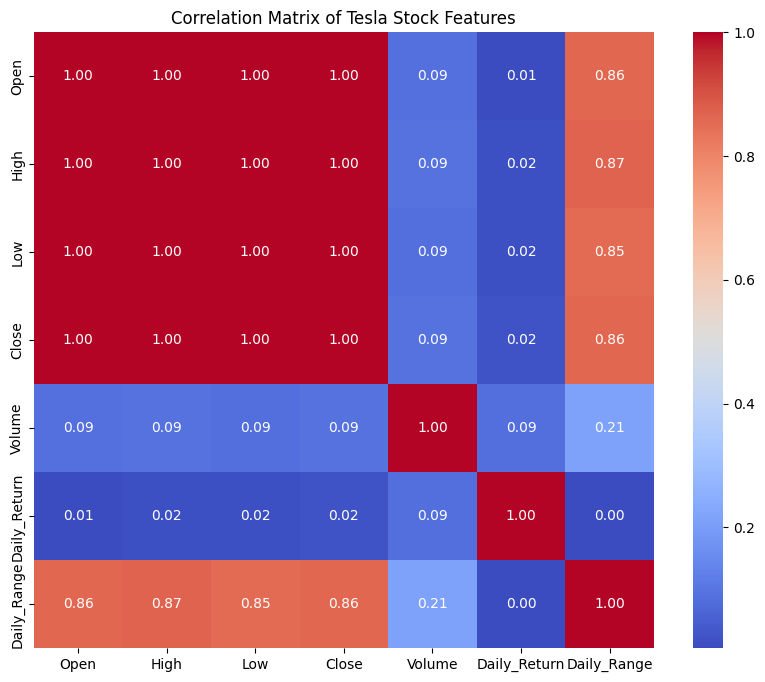

In [14]:
#correlation heatmap - examine the correlation between the numerical columns
numeric_cols = ['Open', 'High', 'Low', 'Close', 'Volume', 'Daily_Return', 'Daily_Range']
correlation_matrix = df[numeric_cols].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Tesla Stock Features')
plt.show()

The correlation heatmap reveals strong positive correlations among 'Open', 'High', 'Low', and 'Close' prices, as expected, while 'Volume', 'Daily_Return', and 'Daily_Range' show varying degrees of correlation with price movements and each other.

In [15]:
#implementing Linear Regression
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

#we will use 'Open', 'High', 'Low', and 'Volume' as features to predict 'Close'
X = df[['Open', 'High', 'Low', 'Volume']]
y = df['Close']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test) #make predictions on the test set

#evaluate the model
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R2): {r2:.2f}")

#display the co-efficients and intercept
print("\nModel Coefficients:")
for feature, coef in zip(X.columns, model.coef_):
  print(f'{feature}: {coef:.4f}')
print(f'Intercept: {model.intercept_:.4f}')

Mean Squared Error (MSE): 20.60
Root Mean Squared Error (RMSE): 4.54
R-squared (R2): 1.00

Model Coefficients:
Open: -0.7118
High: 0.9255
Low: 0.7849
Volume: 0.0000
Intercept: -0.0996


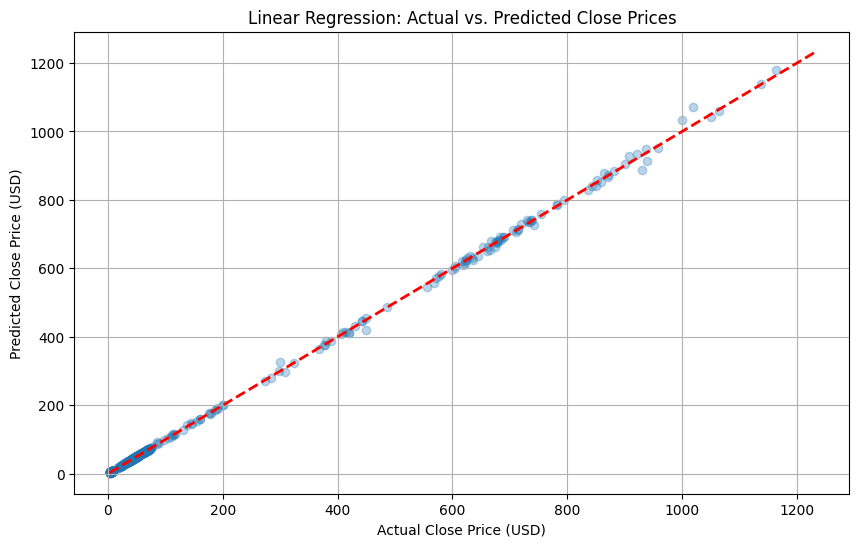

In [16]:
#visualizing actual vs predicted prices - scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.3)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2) #diagonal line for perfect prediction
plt.xlabel('Actual Close Price (USD)')
plt.ylabel('Predicted Close Price (USD)')
plt.title('Linear Regression: Actual vs. Predicted Close Prices')
plt.grid(True)
plt.show()

The scatter plot of actual versus predicted close prices shows that the linear regression model generally performs well, with most predicted values closely aligning with actual values along the diagonal line, indicating high predictive accuracy.

In [17]:
#implementing decision tree regressor and Random Forest Regressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

#decision tree regressor
print('--- Decision Tree Regressor ---')
dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)

mse_dt = mean_squared_error(y_test, y_pred_dt)
rmse_dt = np.sqrt(mse_dt)
r2_dt = r2_score(y_test, y_pred_dt)
print(f"Mean Squared Error (MSE) [DT]: {mse_dt:.2f}")
print(f"Root Mean Squared Error (RMSE) [DT]: {rmse_dt:.2f}")
print(f"R-squared (R2) [DT]: {r2_dt:.2f}")

#random forest regressor
print('\n--- Random Forest Regressor ---')
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_pred_rf)
print(f'Mean Squared Error (MSE) [RF]: {mse_rf:.2f}')
print(f'Root Mean Squared Error (RMSE) [RF]: {rmse_rf:.2f}')
print(f'R-squared (R2) [RF]: {r2_rf:.2f}')

--- Decision Tree Regressor ---
Mean Squared Error (MSE) [DT]: 36.01
Root Mean Squared Error (RMSE) [DT]: 6.00
R-squared (R2) [DT]: 1.00

--- Random Forest Regressor ---
Mean Squared Error (MSE) [RF]: 26.69
Root Mean Squared Error (RMSE) [RF]: 5.17
R-squared (R2) [RF]: 1.00


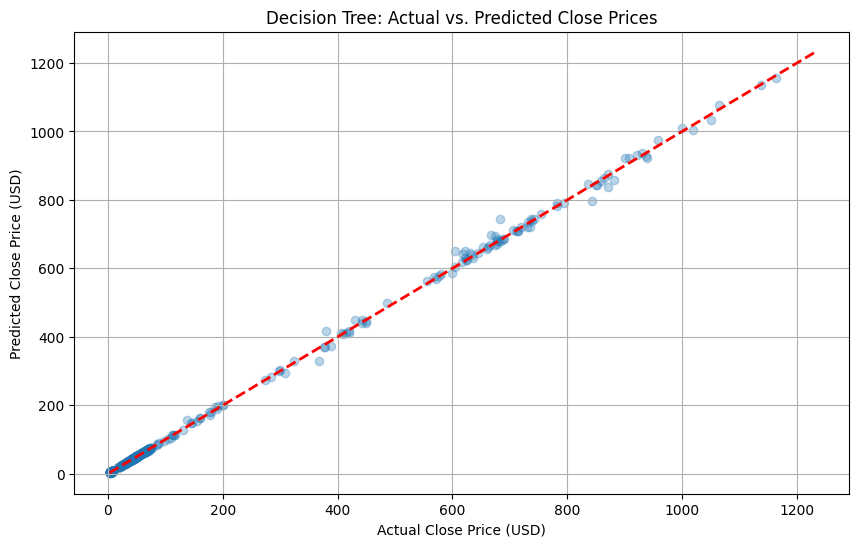

In [18]:
#visualizing actual vs. predicted prices for decision tree and random forest
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_dt, alpha=0.3)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2) #diagonal line for perfect prediction
plt.xlabel('Actual Close Price (USD)')
plt.ylabel('Predicted Close Price (USD)')
plt.title('Decision Tree: Actual vs. Predicted Close Prices')
plt.grid(True)
plt.show()

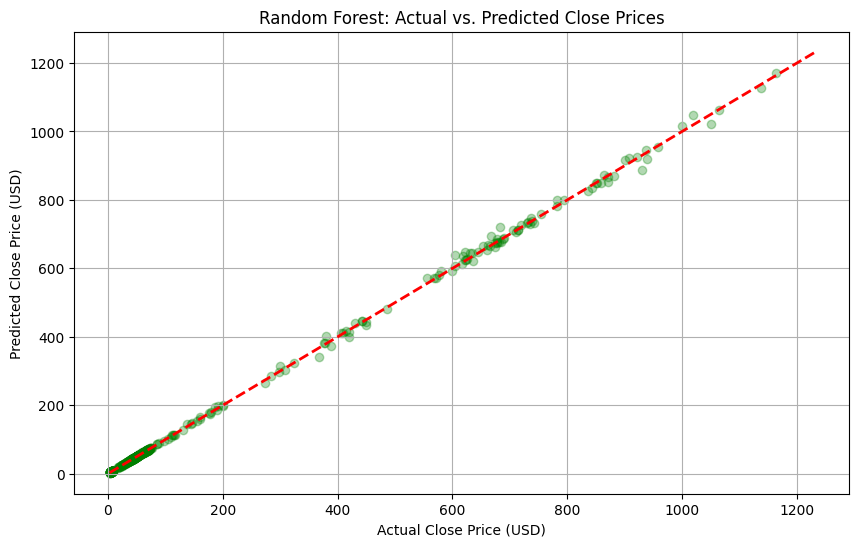

In [19]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_rf, alpha=0.3, color='green')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2) #diagonal line for perfect prediction
plt.xlabel('Actual Close Price (USD)')
plt.ylabel('Predicted Close Price (USD)')
plt.title('Random Forest: Actual vs. Predicted Close Prices')
plt.grid(True)
plt.show()

Both the Decision Tree and Random Forest models demonstrate a strong ability to predict Tesla's closing prices, with actual versus predicted values clustering tightly around the ideal diagonal line, indicating high model accuracy.

### Summary of Model Performances

Based on the evaluation metrics, Linear Regression, Decision Tree, and Random Forest models performed exceptionally well, achieving R-squared scores very close to 1.00. This indicates that they explain almost all the variance in the target variable ('Close' price), meaning their predictions align very closely with the actual closing prices. This strong performance is likely due to the highly correlated nature of 'Open', 'High', 'Low', and 'Close' prices in stock data.

When looking at the error metrics (Mean Squared Error and Root Mean Squared Error), a lower value indicates better performance:

*   **Linear Regression:**
    *   MSE: 20.60
    *   RMSE: 4.54
*   **Random Forest Regressor:**
    *   MSE: 26.69
    *   RMSE: 5.17
*   **Decision Tree Regressor:**
    *   MSE: 36.01
    *   RMSE: 6.00

Considering these error metrics, the Linear Regression model slightly outperformed the other models on this specific dataset, yielding the lowest MSE and RMSE. The Random Forest model followed closely. The Decision Tree model also performed well, though with slightly higher error.